In [ ]:
from PIL import Image

# Load image
image = Image.open("flower.jpg").convert("RGB")  # Convert to RGB format

In [ ]:
# Resize image to 224x224 (or 384x384 depending on model)
image = image.resize((224, 224))

In [ ]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to model input size
])

image = transform(image)

In [ ]:
import torch

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

image = transform(image)  # Apply transformations
image = image.unsqueeze(0)  # Add batch dimension

In [ ]:
augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
])

image = augmentation(image)


In [ ]:
from torchvision import models

# Load pre-trained Swin Transformer model
model = models.swin_v2_t(weights="Swin_V2_T_Weights.DEFAULT")
model.eval()

# Perform inference
with torch.no_grad():
    output = model(image)
    prediction = torch.argmax(output, dim=1)  # Get class label

Downloading: "https://download.pytorch.org/models/swin_v2_t-b137f0e2.pth" to /root/.cache/torch/hub/checkpoints/swin_v2_t-b137f0e2.pth
100%|██████████| 109M/109M [00:00<00:00, 144MB/s] 


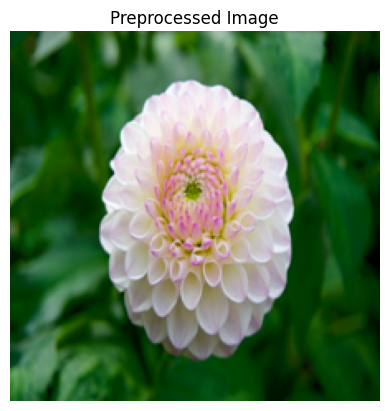

In [ ]:
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# Load and preprocess the image
image = Image.open("flower.jpg").convert("RGB")

# Define transformations (resize, convert to tensor, normalize)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Apply transformation
preprocessed_image = transform(image)

# Convert back to viewable image (Denormalization)
def denormalize(tensor, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    tensor = tensor * std + mean
    tensor = torch.clamp(tensor, 0, 1)  # Ensure values are in [0,1] range
    return tensor

# Denormalize for visualization
denormalized_image = denormalize(preprocessed_image, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

# Convert tensor to numpy for plotting
plt.imshow(denormalized_image.permute(1, 2, 0))  # Convert from CxHxW to HxWxC
plt.axis('off')
plt.title('Preprocessed Image')
plt.show()
